# Ejercicio PCA (Principal Component Analysis)
En este ejercicio vas a trabajar con un dataset de información de ciudadanos como el estado civil, número de hijos, qué gastos e ingresos tiene, etc...

Se cuenta con un target, que es si el ciudadano va a alquilar o a comprar una vivienda. Para ello,  con PCA

### Importamos librerias
Principales librerías que usarás durante el notebook.

In [43]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

### Cargamos datos de entrada
1. Carga el csv *comprar_alquilar.csv*
2. Obtén la información básica: columnas, dimensiones, descripción de las variables, missings...

In [2]:
df = pd.read_csv('data/comprar_alquilar.csv', sep=',')
df.head()

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
0,6000,1000,0,600,50000,400000,0,2,2,1
1,6745,944,123,429,43240,636897,1,3,6,0
2,6455,1033,98,795,57463,321779,2,1,8,1
3,7098,1278,15,254,54506,660933,0,0,3,0
4,6167,863,223,520,41512,348932,0,0,3,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ingresos        202 non-null    int64
 1   gastos_comunes  202 non-null    int64
 2   pago_coche      202 non-null    int64
 3   gastos_otros    202 non-null    int64
 4   ahorros         202 non-null    int64
 5   vivienda        202 non-null    int64
 6   estado_civil    202 non-null    int64
 7   hijos           202 non-null    int64
 8   trabajo         202 non-null    int64
 9   comprar         202 non-null    int64
dtypes: int64(10)
memory usage: 15.9 KB


In [4]:
df.describe()

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
count,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000
mean,4958.995050,971.584158,211.742574,515.425743,38749.668317,373349.638614,1.024752,1.232673,4.490099,0.331683
std,1682.862556,272.106351,124.940754,168.103075,17365.231870,136371.525622,0.837184,1.367833,2.535794,0.471988
min,2008.000000,384.000000,0.000000,201.000000,10319.000000,176553.000000,0.000000,0.000000,0.000000,0.000000
25%,3513.750000,766.750000,99.000000,383.250000,24964.250000,274810.000000,0.000000,0.000000,2.000000,0.000000
50%,4947.500000,968.000000,208.500000,522.500000,38523.000000,340783.500000,1.000000,1.000000,5.000000,0.000000
75%,6374.500000,1165.250000,318.750000,656.750000,52150.750000,444482.000000,2.000000,2.000000,7.000000,1.000000
max,7984.000000,1585.000000,448.000000,828.000000,69934.000000,669540.000000,2.000000,4.000000,8.000000,1.000000


### Visualicemos las dimensiones
Realiza un análisis univariante. Realiza la gráfica que consideres para cada variable, diferenciando por colores el target (*comprar*).

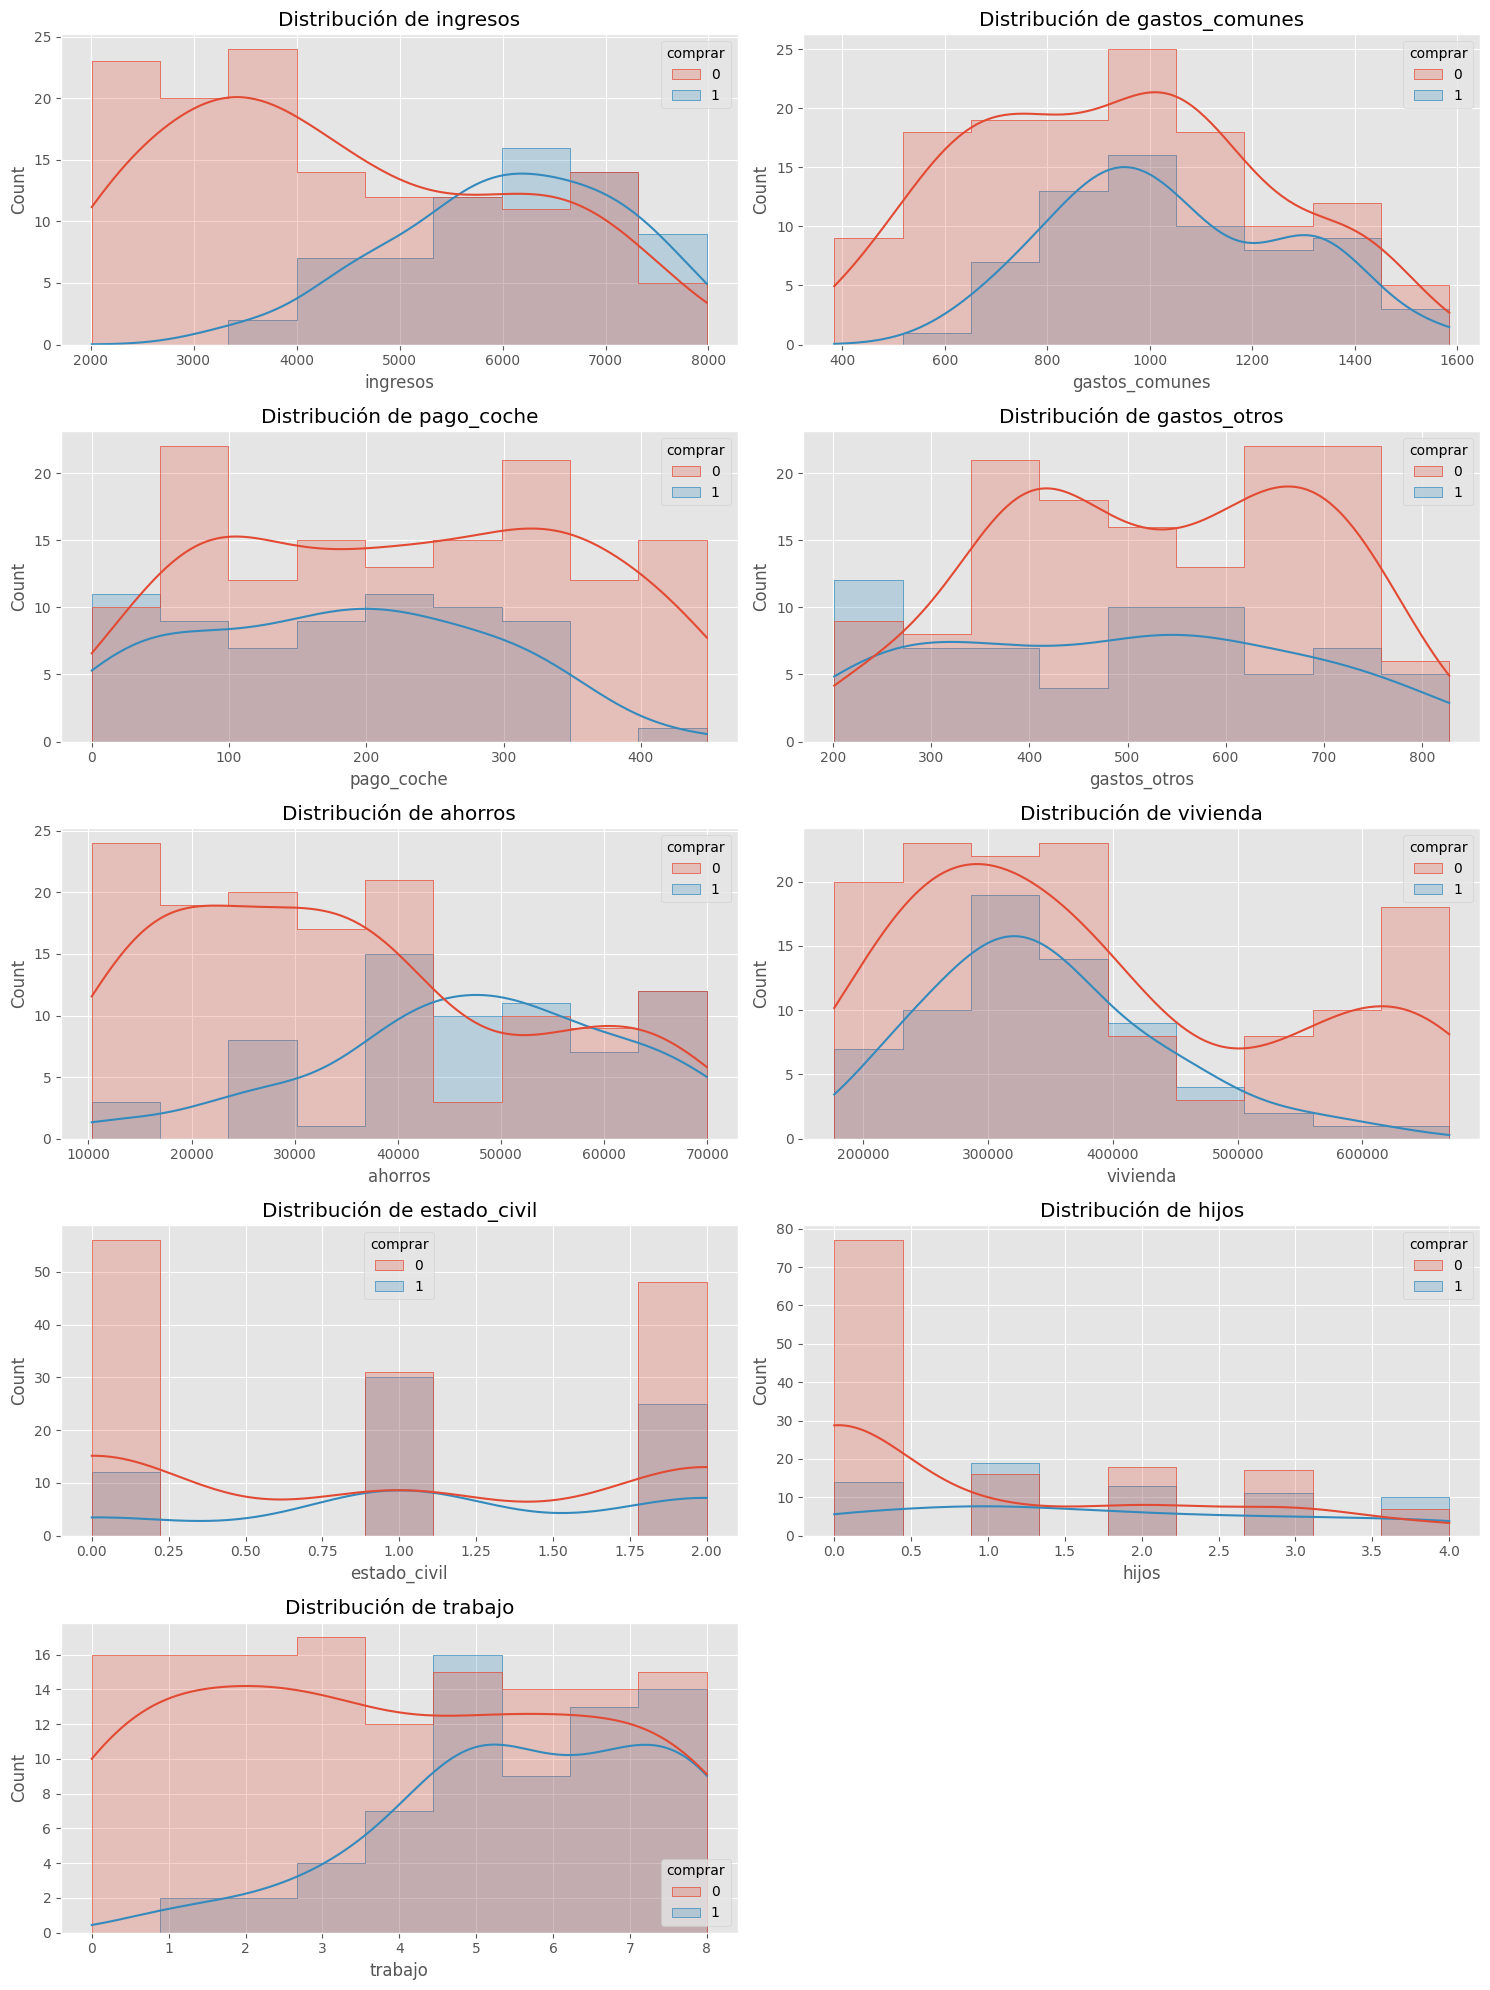

In [5]:
variables = [col for col in df.columns if col != 'comprar']
plt.figure(figsize=(15, 20))
for i, var in enumerate(variables, 1):
    plt.subplot(5, 2, i)
    sns.histplot(data=df, x=var, hue='comprar', kde=True, element='step')
    plt.title(f'Distribución de {var}')
plt.tight_layout()
plt.show()

## Estandariza los datos
Como el objetivo de estos primeros apartados no es encontrar el mejor modelo con el mejor accuracy, por sencillez, no es necesario dividir en train y test.

In [6]:
scaler = StandardScaler()

## Aplicamos PCA
Aplica el algoritmo de PCA para 9 components, es decir, para todas las features

In [7]:
pca = make_pipeline(StandardScaler(), PCA(n_components=9))
pca.fit(df)

modelo = pca['pca']

In [8]:
pca['pca']

PCA(n_components=9)

### Veamos cómo de buenos predictores son las nuevas dimensiones
Responde a las siguientes preguntas:
1. ¿Cuánta varianza explica cada Principal Component?
2. ¿Y de manera acumulada empezando por el PC1?
3. ¿Cuánta varianza explicarían sólo 5 componentes?

In [9]:
# ¿Cuánta varianza explica cada Principal Component?
varianza_individual = modelo.explained_variance_ratio_
print("Varianza explicada por cada componente:")
for i, var in enumerate(varianza_individual, 1):
    print(f"PC{i}: {var:.4f} ({var*100:.2f}%)")

Varianza explicada por cada componente:
PC1: 0.2737 (27.37%)
PC2: 0.2396 (23.96%)
PC3: 0.1099 (10.99%)
PC4: 0.1041 (10.41%)
PC5: 0.0911 (9.11%)
PC6: 0.0735 (7.35%)
PC7: 0.0458 (4.58%)
PC8: 0.0275 (2.75%)
PC9: 0.0247 (2.47%)


In [10]:
# ¿Y de manera acumulada empezando por el PC1?
varianza_acumulada = np.cumsum(varianza_individual)
print("\nVarianza acumulada:")
for i, var in enumerate(varianza_acumulada, 1):
    print(f"PC1 a PC{i}: {var:.4f} ({var*100:.2f}%)")


Varianza acumulada:
PC1 a PC1: 0.2737 (27.37%)
PC1 a PC2: 0.5133 (51.33%)
PC1 a PC3: 0.6232 (62.32%)
PC1 a PC4: 0.7273 (72.73%)
PC1 a PC5: 0.8183 (81.83%)
PC1 a PC6: 0.8919 (89.19%)
PC1 a PC7: 0.9377 (93.77%)
PC1 a PC8: 0.9651 (96.51%)
PC1 a PC9: 0.9898 (98.98%)


In [11]:
# ¿Cuánta varianza explicarían sólo 5 componentes?
varianza_5_componentes = varianza_acumulada[4]
print(f"\nVarianza explicada por 5 componentes: {varianza_5_componentes:.4f} ({varianza_5_componentes*100:.2f}%)")


Varianza explicada por 5 componentes: 0.8183 (81.83%)


### Graficamos la variacion explicada acumulada
Representa en un diagrama de lineas la evolución de la varianza acumulada en función de los PC

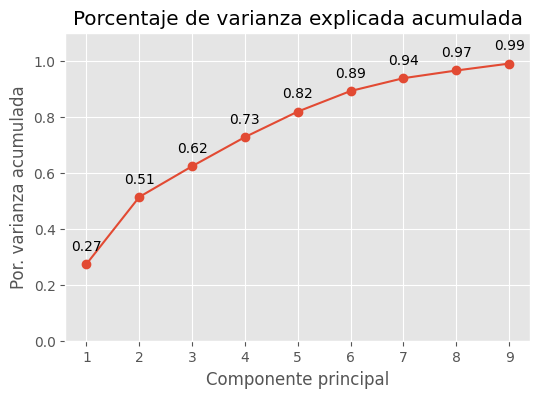

In [12]:
prop_varianza_acum = modelo.explained_variance_ratio_.cumsum()

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.plot(
    np.arange(modelo.n_components_) + 1,
    prop_varianza_acum,
    marker = 'o'
)

for x, y in zip(np.arange(len(df.columns)) + 1, prop_varianza_acum):
    label = round(y, 2)
    ax.annotate(
        label,
        (x,y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )
    
ax.set_ylim(0, 1.1)
ax.set_xticks(np.arange(modelo.n_components_) + 1)
ax.set_title('Porcentaje de varianza explicada acumulada')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza acumulada');

### Veamos la correlación entre las nuevas componentes y las dimensiones originales
Representa en un mapa de calor los PCA vs las variables originales. Esta información la puedes obtener del atributo de PCA *components_*.

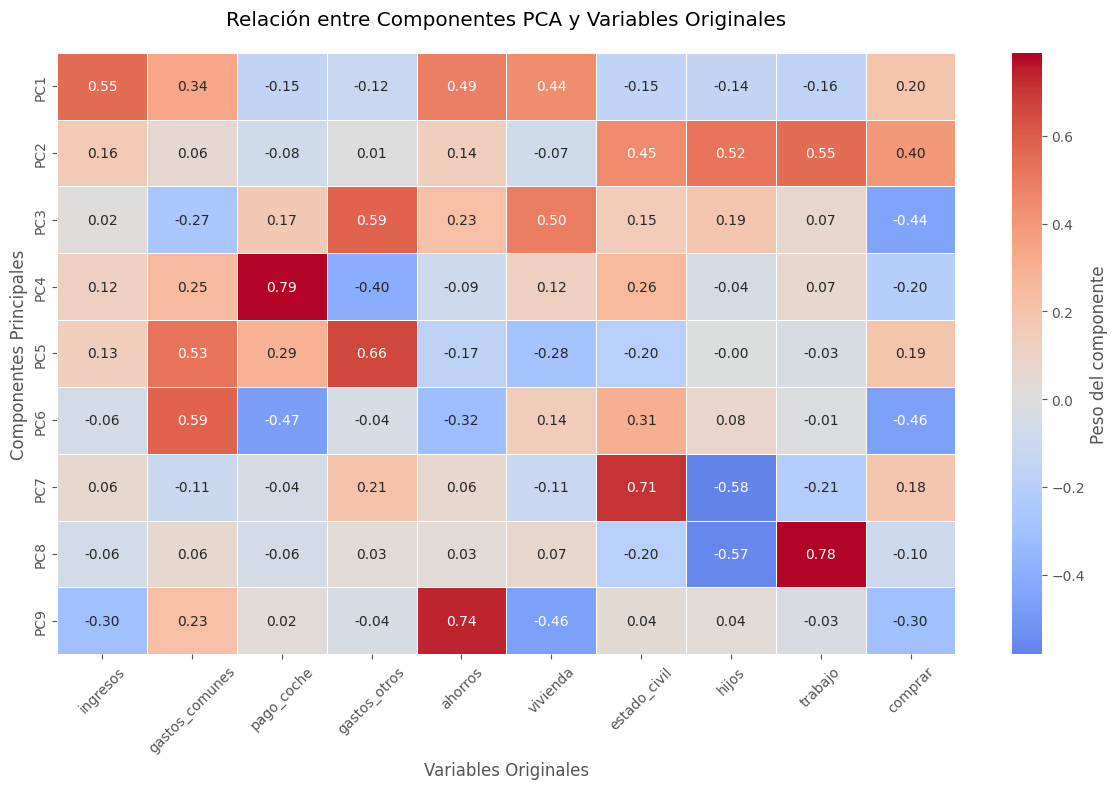

In [21]:
components = modelo.components_

# Crear DataFrame para el mapa de calor
df_components = pd.DataFrame(
    components,
    columns=df.columns,  # Asegúrate de que df es tu DataFrame original
    index=[f'PC{i+1}' for i in range(modelo.n_components_)]
)

# Configurar el tamaño del gráfico
plt.figure(figsize=(12, 8))

# Crear el mapa de calor
sns.heatmap(
    df_components,
    cmap='coolwarm',  # Puedes cambiar el colormap: 'viridis', 'plasma', etc.
    center=0,
    annot=True,  # Muestra los valores en cada celda
    fmt='.2f',   # Formato de 2 decimales
    linewidths=0.5,
    cbar_kws={'label': 'Peso del componente'}
)

# Añadir títulos y ajustes
plt.title('Relación entre Componentes PCA y Variables Originales', pad=20)
plt.xlabel('Variables Originales')
plt.ylabel('Componentes Principales')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Predicciones
1. Divide en train y test
2. Prepara un pipeline compuesto por:
    - StandardScaler,
    - PCA de 5 componentes
    - Un clasificador
3. Entrena
4. Predice con test
5. Calcula el accuracy score en train y test
6. Representa la matriz de confusión
7. ¿Qué combinación de parámetros y componentes mejoraría el accuracy en test?
8. Vuelve a iterar de nuevo con un gridsearch
9. Guarda tu mejor modelo

In [31]:
# Divide en train y test

X = df.drop(columns='comprar')  
y = df['comprar']               

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       
    random_state=10,     
    stratify=y           
)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(161, 9)
(161,)
(41, 9)
(41,)


In [38]:
# Prepara un pipeline compuesto por:
    #- StandardScaler,
    #- PCA de 5 componentes
    #- Un clasificador

pipeline = Pipeline([
    ('scaler', StandardScaler()),       
    ('pca', PCA(n_components=5)),        
    ('clf', LogisticRegression(max_iter=1000))  
])

In [39]:
# Entrena
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=5)),
                ('clf', LogisticRegression(max_iter=1000))])

In [40]:
# Predice con test
y_pred = pipeline.predict(X_test)

In [41]:
# Calcula el accuracy score en train y test
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

Accuracy: 0.8048780487804879

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86        27
           1       0.75      0.64      0.69        14

    accuracy                           0.80        41
   macro avg       0.79      0.77      0.77        41
weighted avg       0.80      0.80      0.80        41



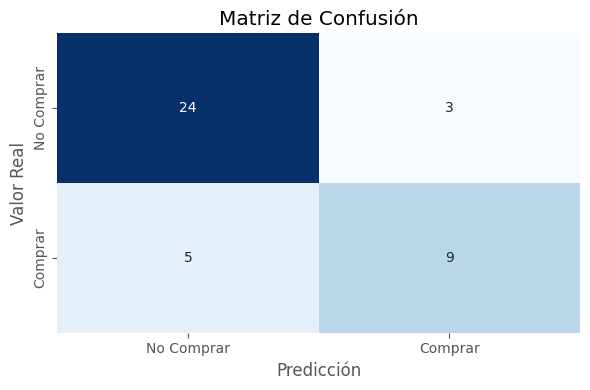

In [42]:
# Representa la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Comprar', 'Comprar'],
            yticklabels=['No Comprar', 'Comprar'])

plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

In [45]:
# ¿Qué combinación de parámetros y componentes mejoraría el accuracy en test?
# n_components de PCA (entre 2 y 9)

# C de LogisticRegression (fuerza de regularización)

In [44]:
# Vuelve a iterar de nuevo con un gridsearch
param_grid = {
    'pca__n_components': [2, 3, 4, 5, 6, 7, 8, 9],  # Probar distintos números de componentes
    'clf__C': [0.01, 0.1, 1, 10, 100]              # Regularización de la regresión logística
}

# Crear el GridSearchCV
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')

# Ajustar sobre el set de entrenamiento
grid.fit(X_train, y_train)

# Mostrar los mejores parámetros
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Evaluar en test
y_pred = grid.predict(X_test)
print("Accuracy en test:", accuracy_score(y_test, y_pred))

Mejores parámetros encontrados:
{'clf__C': 100, 'pca__n_components': 9}
Accuracy en test: 0.9024390243902439


In [46]:
# Guarda tu mejor modelo
import joblib

# Guardar el mejor modelo encontrado por GridSearchCV
joblib.dump(grid.best_estimator_, 'mejor_modelo.pkl')

['mejor_modelo.pkl']

In [49]:
# Cargar el modelo guardado
modelo_cargado = joblib.load('mejor_modelo.pkl')

# Usar para predecir
y_pred = modelo_cargado.predict(X_test)

y_pred


array([0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1])

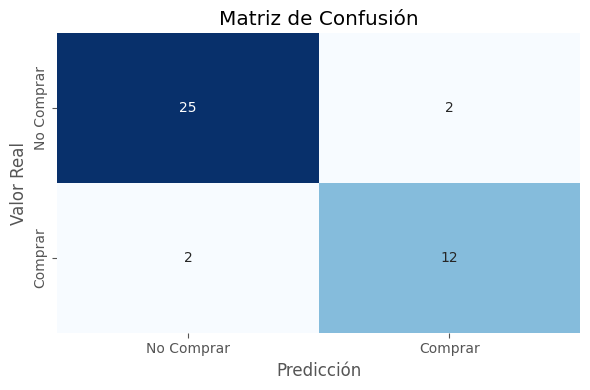

In [50]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Comprar', 'Comprar'],
            yticklabels=['No Comprar', 'Comprar'])

plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show() 